In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [3]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from kret_sandbox.VIS import dtt

In [4]:
config = EnvConfig(max_new_requests_per_step=2, lambda_per_node=0.5)
plt_cfg = PlotConfig()

In [5]:
env = RideShareEnv(config, plt_cfg)
G = env.G
cfg = env.config

Assigned lambda values to nodes. Total lambda: 359.5320 (target: 391.0000)


/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:424: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


In [6]:
s, info = env.reset()

/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:424: UserWarning: WARN: Casting input x to numpy array.
  gym.logger.warn("Casting input x to numpy array.")


In [7]:
def get_obvs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides

In [8]:
veh, req, rides = get_obvs_tuple(env)
veh.shape, req.shape, rides.shape

((2, 6), (25, 21), (2, 18))

In [9]:
dtt([req], how="head")

,request_id,request_dt,cust_id,cust_bias,cust_temperature,est_cost,price,max_wait_time,wait_time,status,pickup_node_id,pickup_x_norm,pickup_y_norm,dropoff_node_id,dropoff_x_norm,dropoff_y_norm,route_nodes,curr_start_node,curr_end_node,route_dist_on_edge,distance_meters
0,403,2025-01-02 11:01:48.507281,3013,4.495,2.179,4.851,NaN,0 days 00:15:00,0 days,0,5482291262,0.739,0.773,42428007,0.405,0.186,"[5482291262, 42443118, 42443116, 42423203, 371239962, 7641820943, 9490559521, 42450468, 4779073679, 4779073680, 3785532381, 6185259892, 42428037, 42428020, 42428007]",5482291262,42443118,0.0,4851.457
1,365,2025-01-02 11:01:48.507281,6149,2.014,1.525,11.832,NaN,0 days 00:15:00,0 days,0,486869282,-0.207,-0.547,371337150,0.701,0.854,"[486869282, 1773076511, 1918039904, 1773082410, 1773084402, 42440729, 42448701, 42436586, 42445378, 42449932, 42449685, 11337295608, 42444051, 42434087, 42438891, 42449956, 42436707, 42449963, 42448379, 42432856, 8133385388, 42449971, 4288677093, 6177439759, 42449985, 42447235, 42436486, 42450015, 42429338, 42450044, 42450057, 42444458, 42443118, 42426135, 3786728788, 6511274595, 371337150]",486869282,1773076511,0.0,11831.853
2,-1,NaT,-1,-1.000,-1.000,-1.000,-1.0,0 days 00:15:00,0 days,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1,-1.0,-1.000
3,-1,NaT,-1,-1.000,-1.000,-1.000,-1.0,0 days 00:15:00,0 days,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1,-1.0,-1.000
4,-1,NaT,-1,-1.000,-1.000,-1.000,-1.0,0 days 00:15:00,0 days,-10,-1,-1.000,-1.000,-1,-1.000,-1.000,[],-1,-1,-1.0,-1.000


In [53]:
action = env.action_space.sample()
dispatches = pd.DataFrame({"dispatch": action["dispatch"]})
prices = pd.DataFrame({"prices": action["prices"]})
reposition = pd.DataFrame(action["reposition"], columns=["x", "y"])
action["dispatch"] = np.full(action["dispatch"].shape, cfg.no_action_id, dtype=np.int32)
action["reposition"] = np.array([[-0.1, -0.1], [0.1, 0.1]], dtype=np.float32)
env.action_space.contains(action)

True

In [54]:
# action["dispatch"][2] = 0
# action["dispatch"][3] = 1
# action["dispatch"]
env._validate_action(action)

In [95]:
obs, reward, terminated, truncated, info = env.step(action)

resetting debug and interim dataframes


In [96]:
veh, req, rides = get_obvs_tuple(env)
req.f_awaiting_price.sum()

np.int64(2)

In [97]:
dtt([env._veh_interim, env._active_rides_debug], how="head")

vehicle_id 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 ride_id 
 
 
 
 
 0 
 0 
 0.756 
 0.73 
 0.862 
 2 
 403 
 
 
 1 
 1 
 -0.209 
 -0.50 
 0.671 
 2 
 365 
 
 
 
 
 
 
 ride_id 
 vehicle_id 
 pickup_node 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 is_complete 
 
 
 
 
 0 
 403 
 0 
 5482291262 
 0.739 
 0.773 
 42428007 
 0.405 
 0.186 
 0.142 
 4.851 
 4851.458008 
 4851.458008 
 4851.458008 
 [5482291262, 42443118, 42443116, 42423203, 371239962, 7641820943, 9490559521, 42450468, 4779073679, 4779073680, 3785532381, 6185259892, 42428037, 42428020, 42428007] 
 5482291262 
 42443118 
 0.0 
 False 
 
 
 1 
 365 
 1 
 486869282 
 -0.207 
 -0.547 
 371337150 
 0.701 
 0.854 
 0.740 
 11.832 
 11831.853516 
 11831.853516 
 11831.853516 
 [486869282, 1773076511, 1918039904, 1773082410, 1773084402, 42440729, 42448701, 42436586, 42445378, 42449932, 42449685, 11337295608, 42444051, 42434087, 42438891, 42449956, 42436707, 42449963, 42448379, 42432856, 8133385388, 42449971, 4288677093, 6177439759, 42449985, 42447235, 42436486, 42450015, 42429338, 42450044, 42450057, 42444458, 42443118, 42426135, 3786728788, 6511274595, 371337150] 
 486869282 
 1773076511 
 0.0 
 False

In [98]:
# dtt([env._request_sanity_df,env._req_interim], samp_head_tail="head")
dtt([req.f_plot_route(plt_cfg), req], n=7, how="head")

0 
 
 
 
 
 0 
 True 
 
 
 1 
 True 
 
 
 2 
 True 
 
 
 3 
 True 
 
 
 4 
 True 
 
 
 5 
 True 
 
 
 6 
 True 
 
 
 
 
 
 
 request_id 
 request_dt 
 cust_id 
 cust_bias 
 cust_temperature 
 est_cost 
 price 
 max_wait_time 
 wait_time 
 status 
 pickup_node_id 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node_id 
 dropoff_x_norm 
 dropoff_y_norm 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 distance_meters 
 
 
 
 
 0 
 2091 
 2025-01-02 11:09:48.507281 
 40119 
 1.785 
 1.587 
 9.738 
 NaN 
 0 days 00:15:00 
 0 days 00:00:00 
 0 
 42424610 
 -0.451 
 -0.538 
 42421737 
 0.262 
 0.693 
 [42424610, 42424408, 4142105822, 12417264049, 42436374, 42432214, 42435624, 42435644, 42435646, 42435650, 42435663, 42432700, 42435675, 42432589, 42435684, 42435705, 42435707, 42435714, 1825841704, 1825841655, 42428575, 42428588, 13208007103, 9170816532, 3718672443, 42443336, 42443347, 42443280, 42443353, 42443381, 42421737] 
 42424610 
 42424408 
 0.0 
 9737.847 
 
 
 1 
 2250 
 2025-01-02 11:09:48.507281 
 31575 
 2.022 
 1.407 
 10.086 
 NaN 
 0 days 00:15:00 
 0 days 00:00:00 
 0 
 371239958 
 0.790 
 0.662 
 42454391 
 0.071 
 -0.563 
 [371239958, 371209940, 42424025, 3785532382, 42428052, 6185259892, 42428037, 42428020, 42428007, 42427970, 42427968, 42427965, 371188750, 13238997597, 589099734, 42445392, 370912817, 42426865, 370898427, 42423549, 42454391] 
 371239958 
 371209940 
 0.0 
 10086.341 
 
 
 2 
 1903 
 2025-01-02 11:08:48.507281 
 39882 
 1.348 
 1.734 
 5.686 
 0.864 
 0 days 00:15:00 
 0 days 00:01:00 
 1 
 42434074 
 0.035 
 0.006 
 42445357 
 -0.457 
 -0.610 
 [42434074, 42444043, 42445916, 42437358, 42443950, 42452973, 42437644, 42430304, 42430271, 42430237, 4321748237, 4321748238, 3891963915, 42430143, 3788379733, 4143859865, 4778174564, 3567807957, 42434845, 42445357] 
 42434074 
 42444043 
 0.0 
 5685.959 
 
 
 3 
 2033 
 2025-01-02 11:08:48.507281 
 35049 
 1.194 
 1.946 
 4.902 
 0.241 
 0 days 00:15:00 
 0 days 00:01:00 
 1 
 4143859865 
 -0.402 
 -0.521 
 42434074 
 0.035 
 0.006 
 [4143859865, 3788379733, 42430143, 3891963915, 4321748238, 4321748237, 42430237, 42430271, 42430304, 42437644, 42452973, 42443950, 42437358, 42445916, 42444043, 42434074] 
 4143859865 
 3788379733 
 0.0 
 4902.195 
 
 
 4 
 1791 
 2025-01-02 11:07:48.507281 
 18337 
 1.833 
 1.464 
 5.885 
 0.864 
 0 days 00:15:00 
 0 days 00:02:00 
 1 
 1061531654 
 0.186 
 0.725 
 42434072 
 0.010 
 0.016 
 [1061531654, 1061531807, 1061531593, 1061531603, 42428674, 42428653, 42428634, 9177424867, 42428595, 9915469771, 42428588, 42428575, 1825841655, 1825841704, 1825841743, 42428329, 42440022, 42440015, 42430371, 42430367, 42430358, 42440153, 42432580, 42434072] 
 1061531654 
 1061531807 
 0.0 
 5884.871 
 
 
 5 
 1766 
 2025-01-02 11:07:48.507281 
 18999 
 3.942 
 1.301 
 4.215 
 0.241 
 0 days 00:15:00 
 0 days 00:02:00 
 1 
 370894980 
 0.080 
 -0.527 
 42442952 
 0.174 
 -0.002 
 [370894980, 370897166, 370913758, 42422509, 42457925, 42445392, 589099734, 6176628861, 42422899, 12154055788, 42455929, 42442937, 42442947, 42434090, 42438894, 42442952] 
 370894980 
 370897166 
 0.0 
 4214.767 
 
 
 6 
 1431 
 2025-01-02 11:06:48.507281 
 3111 
 -0.363 
 2.113 
 1.611 
 0.864 
 0 days 00:15:00 
 0 days 00:03:00 
 1 
 42430333 
 -0.070 
 -0.002 
 42444055 
 0.176 
 -0.066 
 [42430333, 42437358, 42445916, 11337295604, 11337295608, 42442937, 42455929, 595105472, 42444055] 
 42430333 
 42437358 
 0.0 
 1610.856

In [99]:
# env.observation_curr["pending_requests"]

In [100]:
from waymo_agent.data_classes.osmnx_constants import DEFAULT_OX_PLOT_NOTEBOOK


plt_cfg = PlotConfig()
# plt_cfg.ox_plot_default["bgcolor"] = "white"
# plt_cfg.ox_plot_default["bgcolor"]

In [101]:
fig, ax = env.render(plt_cfg=plt_cfg)

# fig

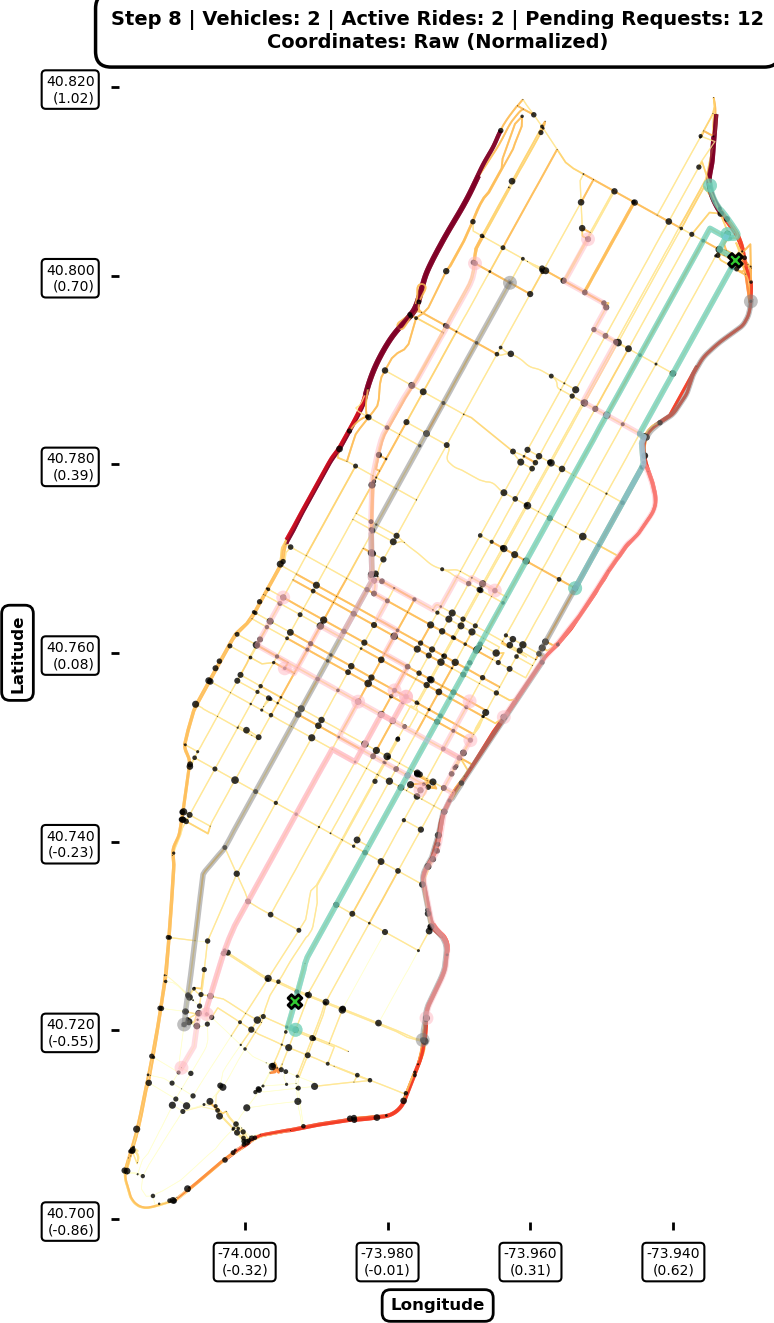

In [102]:
fig